<a href="https://colab.research.google.com/github/JoseAlberto88/Predictive-Analytics-/blob/main/DAMO510_Module_06_Summer26_starter_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DAMO510 - Module 06: Logistic Regression


### Main points you should remember from previous modules and some new stuff!!

- The train-test split should occur before any learned preprocessing.

- Missing-value imputation should be fitted on the training data only. why?

- Box-Cox / Yeo-Johnson transformations should be fitted using the training data only.

- Because of the large scale differences between your features, I reccomend applying the `StandardScaler` and of course fitting on the training data only.

- `OneHotEncoder` should be fitted on the training data only.

- For DataFrame versions use `.copy()` rather than aliases.

- The same train-test split is used for both modeling stages.

- Stage 3 means **no power transformation of numerical predictors**; scaling is retained because regularized logistic regression is scale-sensitive.

- You dont need to apply ordinal encoding cuz no predictors requiring `OrdinalEncoder` are poresent in the dataset.

- The target is already coded as 0/1, so `LabelEncoder` is unnecessary.

> Important: Power transformation is investigated here as a modeling choice. Logistic regression does **not** require predictors themselves to be normally distributed.

In [10]:
# I have already save the enam_sample_telemetry dataset in my google drive acount. So, we'll call them and later check that load_enam_csv function is
# working well

# Connect to Google Drive

from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.


# 1. Imports and Reproducibility

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import skew

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    recall_score,
    precision_score
)

RANDOM_STATE = 88
SKEW_THRESHOLD = 0.50

In [13]:
# 1.2 Load dataset for profiling

DATA_FILE = '/content/drive/MyDrive/Predictive Analytics Course/PCOS_data_without_infertility_tailored.xlsx'
df_a = pd.read_excel(DATA_FILE, sheet_name = "Full_new")

print("Initial shape:", df_a.shape)
df_a.head()

Initial shape: (536, 45)


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Column1
0,1,1,0,28,44.6,152.0,19.3,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,NaN,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,NaN,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,NaN,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,NaN,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


# 2. Stage 1: Load the dataset

Notice you have two worksheets in the excell dataset.

## 2.1 Initial quality checks

In [14]:
print("Duplicate rows:", df_a.duplicated().sum())

missing_initial = df_a.isna().sum()
print("\nColumns with missing values:")
print(missing_initial[missing_initial > 0])

Duplicate rows: 0

Columns with missing values:
BMI                      294
Marraige Status (Yrs)      1
FSH/LH                   527
Waist:Hip Ratio          527
Fast food (Y/N)            1
Column1                  534
dtype: int64


In [15]:
df_a.shape


(536, 45)

## 2.2 Remove irrelevant fields and rename columns

`Sl. No` and `Patient File No.` are identifiers rather than meaningful clinical predictors.  
`Column1` is essentially empty and should be removed.

Create a new DataFrame using `.copy()` so that later edits do not modify earlier versions.

In [16]:
df_b = df_a.drop(columns = ["Sl. No", "Patient File No.", "Column1"]).copy()

new_column_names = [
    "PCOS_Diagnosis", "Age", "Weight", "Height", "Body_Mass_Index",
    "Blood_Type", "Pulse_Rate", "Respiratory_Rate", "Hemoglobin",
    "Cycle_Regularity", "Cycle_Length", "Marriage_History", "Pregnant",
    "Abortions", "Beta_HCG_1", "Beta_HCG_2", "FSH", "LH", "FSH_LH_Ratio",
    "Hip", "Waist", "Waist_Hip_Ratio", "TSH", "AMH", "Prolactin",
    "Vitamin_D3", "Progesterone", "Random_Blood_Sugar", "Weight_Gain",
    "Hair_Growth", "Skin_Darkening", "Hair_Loss", "Pimples", "Fast_Food",
    "Regular_Exercise", "BP_Systolic", "BP_Diastolic",
    "Follicle_Count_Left", "Follicle_Count_Right",
    "Avg_Follicle_Size_Left", "Avg_Follicle_Size_Right",
    "Endometrium_Thickness"
]

df_b.columns = new_column_names

print("Shape after removing irrelevant fields:", df_b.shape)
df_b.head()

Shape after removing irrelevant fields: (536, 42)


,PCOS_Diagnosis,Age,Weight,Height,Body_Mass_Index,Blood_Type,Pulse_Rate,Respiratory_Rate,Hemoglobin,Cycle_Regularity,...,Pimples,Fast_Food,Regular_Exercise,BP_Systolic,BP_Diastolic,Follicle_Count_Left,Follicle_Count_Right,Avg_Follicle_Size_Left,Avg_Follicle_Size_Right,Endometrium_Thickness
0,0,28,44.6,152.0,19.3,15,78,22,10.48,2,...,0,1.0,0,110,80,3,3,18.0,18.0,8.5
1,0,36,65.0,161.5,NaN,15,74,20,11.70,2,...,0,0.0,0,120,70,3,5,15.0,14.0,3.7
2,1,33,68.8,165.0,NaN,11,72,18,11.80,2,...,1,1.0,0,120,80,13,15,18.0,20.0,10.0
3,0,37,65.0,148.0,NaN,13,72,20,12.00,2,...,0,0.0,0,120,70,2,2,15.0,14.0,7.5
4,0,25,52.0,161.0,NaN,11,72,18,10.00,2,...,0,0.0,0,120,80,3,4,16.0,14.0,7.0


In [20]:
df_b["PCOS_Diagnosis"].value_counts()


,count
PCOS_Diagnosis,
0,360
1,176


## 2.3 Correct Data-Type and category inconsistencies - without imputing yet

In [21]:
df_c = df_b.copy()

# Convert malformed/non-numeric entries to numeric.

# A trailing period such as '1.99.' is corrected before conversion.

df_c["Beta_HCG_2"] = (
    df_c["Beta_HCG_2"]
    .astype(str)
    .str.strip()
    .str.rstrip(".")
)
df_c["Beta_HCG_2"] = pd.to_numeric(df_c["Beta_HCG_2"], errors = "coerce")

# errors="coerce" means that any value that cannot be converted to a number is replaced with NaN (a missing value) instead of causing an error.

df_c["AMH"] = pd.to_numeric(df_c["AMH"], errors = "coerce")

# According to the data dictionary:
# 2 = Regular and 4 = Irregular.
# Any other value is treated as invalid/missing.

invalid_cycle = ~df_c["Cycle_Regularity"].isin([2, 4])

df_c.loc[invalid_cycle, "Cycle_Regularity"] = np.nan

'''
another way of doing the above task is:
df_c["Cycle_Regularity"] = df_c["Cycle_Regularity"].where(df_c["Cycle_Regularity"].isin([2, 4]))

'''

print("Cycle values after cleaning:", df_c["Cycle_Regularity"].unique())

print("\nMissing values after correcting inconsistencies:")
missing_after_cleaning = df_c.isna().sum()
print(missing_after_cleaning[missing_after_cleaning > 0])

Cycle values after cleaning: [ 2.  4. nan]

Missing values after correcting inconsistencies:
Body_Mass_Index     294
Cycle_Regularity      1
Marriage_History      1
FSH_LH_Ratio        527
Waist_Hip_Ratio     527
AMH                   1
Fast_Food             1
dtype: int64


### reminder: Dont apply any missing-value imputation here

Median/mode values are learned from data. If we compute them before the train-test split, information from the future test set enters preprocessing.

Therefore, missing values are **kept as missing until after the split**.

## 2.4 Feature Engineering: Creating Clinically Meaningful Predictors

Some individual measurements may become more informative when they are combined into clinically meaningful ratios or indices.

- BMI relates body weight to height and provides a more useful measure of body composition than weight alone.

- Waist-to-hip ratio provides information about the distribution of body fat, particularly central or abdominal fat.

- FSH/LH ratio describes the relationship between two reproductive hormones rather than considering their concentrations independently.

>Because PCOS is associated with metabolic, body-composition, and hormonal characteristics, these engineered features may provide the logistic regression model with additional predictive information. In this activity, the dataset already identifies BMI, FSH/LH ratio, and waist-to-hip ratio as predictors, so we will reconstruct these aggregated fields from their underlying measurements where appropriate. This way we can address any potential missing value of these features in the dataset as well.

##Instructions

Feature Engineering: Using the existing variables in the dataset, calculate the following three derived features:

1. Body Mass Index (BMI): Calculate BMI using weight in kilograms and height in metres. Remember that height is currently recorded in centimetres, so it must first be converted to metres.

2. FSH/LH Ratio: Calculate the ratio of FSH to LH by dividing each patient's FSH measurement by their LH measurement.

3. Waist-to-Hip Ratio: Calculate the ratio of waist circumference to hip circumference.

Store the calculated values in the existing fields Body_Mass_Index, FSH_LH_Ratio, and Waist_Hip_Ratio. After completing the feature-engineering step, display the first five rows of these three variables to verify your calculations.

In [22]:
df_d = df_c.copy()

# Height is stored in centimetres.
df_d["Body_Mass_Index"] = (df_d["Weight"] / (df_d["Height"] / 100) ** 2)

df_d["FSH_LH_Ratio"] = df_d["FSH"] / df_d["LH"]

df_d["Waist_Hip_Ratio"] = df_d["Waist"] / df_d["Hip"]

df_d[["Body_Mass_Index", "FSH_LH_Ratio", "Waist_Hip_Ratio"]].head()

,Body_Mass_Index,FSH_LH_Ratio,Waist_Hip_Ratio
0,19.304017,2.160326,0.833333
1,24.921163,6.174312,0.842105
2,25.270891,6.295455,0.900000
3,29.674945,3.415254,0.857143
4,20.060954,4.422222,0.810811


## 2.5 Remove redundant raw predictors

Remove the components used to form BMI, FSH/LH ratio, and waist/hip ratio.

This is a modeling choice rather than a universal rule. In another analysis, we could test whether retaining the original variables improves predictive performance.

In [27]:
df_e = df_d.drop(columns = ["Weight", "Height", "FSH", "LH", "Hip", "Waist"]).copy()

print("Modeling DataFrame shape:", df_e.shape)
print(df_e.head())
print(df_e.columns)

Modeling DataFrame shape: (536, 36)
   PCOS_Diagnosis  Age  Body_Mass_Index  Blood_Type  Pulse_Rate  \
0               0   28        19.304017          15          78   
1               0   36        24.921163          15          74   
2               1   33        25.270891          11          72   
3               0   37        29.674945          13          72   
4               0   25        20.060954          11          72   

   Respiratory_Rate  Hemoglobin  Cycle_Regularity  Cycle_Length  \
0                22       10.48               2.0             5   
1                20       11.70               2.0             5   
2                18       11.80               2.0             5   
3                20       12.00               2.0             5   
4                18       10.00               2.0             5   

   Marriage_History  ...  Pimples  Fast_Food  Regular_Exercise  BP_Systolic  \
0               7.0  ...        0        1.0                 0          110   


# 3. Define target and feature types

In [28]:
target = "PCOS_Diagnosis"

nominal_features = [
    "Blood_Type",
    "Cycle_Regularity",
    "Pregnant",
    "Weight_Gain",
    "Hair_Growth",
    "Skin_Darkening",
    "Hair_Loss",
    "Pimples",
    "Fast_Food",
    "Regular_Exercise"
]

# No genuinely ordinal predictors requiring OrdinalEncoder were identified.

ordinal_features = []

numeric_features = [
    col for col in df_e.columns
    if col not in nominal_features + ordinal_features + [target]
]

print("Number of numerical predictors:", len(numeric_features))
print("Number of nominal predictors:", len(nominal_features))
print("Number of ordinal predictors:", len(ordinal_features))

Number of numerical predictors: 25
Number of nominal predictors: 10
Number of ordinal predictors: 0


# 4. Train-Test split before learned preprocessing

In [25]:
X = df_e.drop(columns = [target]).copy()

y = df_e[target].astype(int).copy() #is mainly a step to guarantee that the target is stored as integers rather than 0.0 and 1.0 etc.

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state = RANDOM_STATE,
    stratify = y # `stratify=y` keeps the PCOS / non-PCOS class proportions similar in the training and test sets.
)

print("Training shape:", X_train_raw.shape)
print("Testing shape:", X_test_raw.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize = False).sort_index())
print(y_train.value_counts(normalize = True).sort_index())

print("\nTesting target distribution:")
print(y_test.value_counts(normalize = True).sort_index())

Training shape: (428, 35)
Testing shape: (108, 35)

Training target distribution:
PCOS_Diagnosis
0    287
1    141
Name: count, dtype: int64
PCOS_Diagnosis
0    0.670561
1    0.329439
Name: proportion, dtype: float64

Testing target distribution:
PCOS_Diagnosis
0    0.675926
1    0.324074
Name: proportion, dtype: float64


From this point forward, **all learned preprocessing should be fitted on `X_train_raw` only** and then applied to `X_test_raw`.

# 5. Training-Only Imputation

# Missing-Value Imputation

After splitting the data into training and testing sets, handle the remaining missing values using `SimpleImputer` from scikit-learn.

1. Numerical predictors: Create a SimpleImputer that uses the median as the imputation strategy. Fit the imputer only on the numerical predictors in the training dataset, and use it to transform the training data. Then use the same fitted imputer to transform the numerical predictors in the test dataset. **Do not fit the imputer again on the test data**.

2. Nominal predictors: Create a second SimpleImputer using the most frequent value (mode) as the imputation strategy. Again, fit it only on the nominal predictors in the training dataset, and then use the same fitted imputer to transform both the training and test nominal predictors.

3. Convert the transformed results back into pandas DataFrames, preserving the original feature names and row indices.

4. Finally, verify that the imputation was successful by calculating and displaying the total number of remaining missing values in each of the four resulting datasets.

> Important: All imputation rules must be learned from the training data only. This prevents information from the test dataset from influencing the preprocessing process and avoids data leakage.


In [30]:
# Numerical predictors: using the median
from sklearn.impute import SimpleImputer

# Numerical predictors, we will fill the missing values with median
num_imputer = SimpleImputer(strategy="median")

X_train_num = pd.DataFrame(
    num_imputer.fit_transform(X_train_raw[numeric_features]),
    columns=numeric_features,
    index=X_train_raw.index
)

X_test_num = pd.DataFrame(
    num_imputer.transform(X_test_raw[numeric_features]),
    columns=numeric_features,
    index=X_test_raw.index
)

# Nominal predictors, we will use the most frequency for ecah categorical variable
nom_imputer = SimpleImputer(strategy="most_frequent")

X_train_nom = pd.DataFrame(
    nom_imputer.fit_transform(X_train_raw[nominal_features]),
    columns=nominal_features,
    index=X_train_raw.index
)

X_test_nom = pd.DataFrame(
    nom_imputer.transform(X_test_raw[nominal_features]),
    columns=nominal_features,
    index=X_test_raw.index
)

# --- Verification ---
print("Remaining missing values in training numerics:", X_train_num.isnull().sum().sum())
print("Remaining missing values in test numerics:", X_test_num.isnull().sum().sum())
print("Remaining missing values in training nominal data:", X_train_nom.isnull().sum().sum())
print("Remaining missing values in test nominal data:", X_test_nom.isnull().sum().sum())


Remaining missing values in training numerics: 0
Remaining missing values in test numerics: 0
Remaining missing values in training nominal data: 0
Remaining missing values in test nominal data: 0


Remaining missing values in training numerics: 0
Remaining missing values in test numerics: 0
Remaining missing values in training nominal data: 0
Remaining missing values in test nominal data: 0


# 6. One-Hot encoding

# One-Hot encoding of nominal predictors

After handling the missing values, convert the nominal categorical predictors into numerical variables using OneHotEncoder from scikit-learn.

Create a OneHotEncoder and configure it to:

- Drop the first category from each nominal feature to avoid creating redundant dummy variables.

- Ignore unknown categories that may appear in the test data but were not present in the training data.

- Return the encoded data as a dense array rather than a sparse matrix.

- Include compatibility handling so that the code works with both newer and older versions of scikit-learn (sparse_output = False in newer versions and sparse = False in older versions).(basically, create a try-except block)

- Fit and transform the training nominal predictors using the encoder. The categories used for encoding must be learned from the training data only.
Use the same fitted encoder to transform the test nominal predictors. Do not fit a separate encoder on the test data, as this could result in inconsistent columns and data leakage.

- Retrieve the names of the newly generated dummy variables from the fitted encoder. Include compatibility handling for both newer (get_feature_names_out()) and older (get_feature_names()) versions of scikit-learn.(basically, create a try-except block).

- Convert the encoded training and testing arrays back into pandas DataFrames.

- Assign the generated dummy-variable names as the column names and preserve the original row indices.

- Finally, display the shape of the encoded training and testing datasets. Confirm that both datasets contain the same number of encoded predictor columns.


In [31]:
# Ensure compatibility with newer and older scikit-learn releases.
try:
    ohe = OneHotEncoder(
        drop = "first",
        handle_unknown = "ignore",
        sparse_output = False
    )
except TypeError:
    ohe = OneHotEncoder(
        drop = "first",
        handle_unknown = "ignore",
        sparse = False
    )

## ...

In [32]:
# Fit on training nominal data only, then transform both train and test
X_train_nom_enc = ohe.fit_transform(X_train_nom)
X_test_nom_enc = ohe.transform(X_test_nom)

# Retrieve dummy variable names, with compatibility handling
try:
    ohe_feature_names = ohe.get_feature_names_out(nominal_features)
except AttributeError:
    ohe_feature_names = ohe.get_feature_names(nominal_features)

# Convert back into DataFrames, preserving row indices and assigning column names
X_train_nom_enc = pd.DataFrame(
    X_train_nom_enc,
    columns=ohe_feature_names,
    index=X_train_nom.index
)

X_test_nom_enc = pd.DataFrame(
    X_test_nom_enc,
    columns=ohe_feature_names,
    index=X_test_nom.index
)

# Verification
print("Encoded training shape:", X_train_nom_enc.shape)
print("Encoded testing shape:", X_test_nom_enc.shape)
print("Same number of columns:", X_train_nom_enc.shape[1] == X_test_nom_enc.shape[1])



Encoded training shape: (428, 16)
Encoded testing shape: (108, 16)
Same number of columns: True


# 7. Stage 2 - Logistic Regression with numerical power transformation

Transformation decisions are based on **training-set skewness only**.

- If `|skewness| > 0.50`, the feature is considered meaningfully skewed for this activity.

- Box-Cox is used for strictly positive variables.

- Yeo-Johnson is used where zero is possible or values are not strictly positive.

- Features below the skewness threshold are not power-transformed.

Some clinical count/size variables can legitimately be zero even if no zero happens to appear in one particular training split. **They are therefore treated as zero-capable and use Yeo-Johnson when skewed**.

# Identifying numerical features for power transformation

Before applying Box-Cox or Yeo-Johnson transformations, examine the numerical predictors in the training dataset and determine which variables are sufficiently skewed to require transformation.

1. Create a set named zero_capable_features containing numerical variables that can legitimately take a value of zero. These variables should not use Box-Cox, because Box-Cox requires all values to be strictly greater than zero.

2. Create an empty list called transformation_plan. This list will later store a summary showing each feature, its skewness value, and the selected transformation method.

3. Create three additional empty lists:
- boxcox_features for skewed predictors suitable for Box-Cox,
- yeojohnson_features for skewed predictors that may contain zero or non-positive values,
- no_power_features for predictors that do not require a power transformation.

4. Loop through every variable in numeric_features.
For each numerical predictor, calculate its skewness using only the training data. Use bias = False when calculating skewness (Use bias=False to obtain a sample-size-adjusted estimate of skewness, since our training data represents a sample rather than the entire population).

5. Compare the absolute skewness value with the previously defined SKEW_THRESHOLD. If the absolute skewness is less than or equal to the threshold, classify the feature as requiring no power transformation.
If the absolute skewness is greater than the threshold, determine whether Box-Cox or Yeo-Johnson should be used.

6. Assign Box-Cox when:
- all observed training values are strictly greater than zero, and
the variable is not one of the predefined zero_capable_features.

7. Assign Yeo-Johnson when the feature is sufficiently skewed but either:
zero or negative values are possible/present, or the feature belongs to the zero_capable_features set.

8. Add each feature to the appropriate list: boxcox_features, yeojohnson_features, or no_power_features.

9. For every predictor, store the following information in transformation_plan:
feature name, training-set skewness rounded to three decimal places,
selected transformation method.

10. Convert transformation_plan into a pandas DataFrame called transformation_plan_df and display it so that the transformation decision for every numerical predictor can be reviewed before actually applying the transformations.

> Important: The decision about which transformation to use must be based only on the training data. The test data should not influence either the skewness calculation or the transformation-selection process.

In [33]:
from scipy.stats import skew

SKEW_THRESHOLD = 0.50

# 1. Zero-capable features: clinical variables that can legitimately be zero,
#    even if the training split happens not to contain a zero.
zero_capable_features = {
    "Abortions",
    "Follicle_Count_Left",
    "Follicle_Count_Right",
    "Avg_Follicle_Size_Left",
    "Avg_Follicle_Size_Right"
}

# 2 & 3. Storage lists
transformation_plan = []
boxcox_features = []
yeojohnson_features = []
no_power_features = []

# 4-8. Loop through numeric features, using training data only
for feature in numeric_features:
    train_values = X_train_num[feature]

    # Skewness computed on training data only, bias-corrected
    feature_skew = skew(train_values, bias=False)

    if abs(feature_skew) <= SKEW_THRESHOLD:
        method = "None"
        no_power_features.append(feature)
    else:
        all_strictly_positive = (train_values > 0).all()

        if all_strictly_positive and feature not in zero_capable_features:
            method = "Box-Cox"
            boxcox_features.append(feature)
        else:
            method = "Yeo-Johnson"
            yeojohnson_features.append(feature)

    # 9. Record the decision
    transformation_plan.append({
        "Feature": feature,
        "Training Skewness": round(feature_skew, 3),
        "Transformation": method
    })

# 10. Convert to DataFrame and display
transformation_plan_df = pd.DataFrame(transformation_plan)
transformation_plan_df

,Feature,Training Skewness,Transformation
0,Age,0.327,None
1,Body_Mass_Index,0.189,None
2,Pulse_Rate,1.234,Box-Cox
3,Respiratory_Rate,1.390,Box-Cox
4,Hemoglobin,0.825,Box-Cox
5,Cycle_Length,0.965,Box-Cox
6,Marriage_History,1.258,Box-Cox
7,Abortions,2.868,Yeo-Johnson
8,Beta_HCG_1,6.748,Box-Cox
9,Beta_HCG_2,11.601,Box-Cox


,Feature,Training Skewness,Transformation
0,Age,0.327,None
1,Body_Mass_Index,0.189,None
2,Pulse_Rate,1.234,Box-Cox
3,Respiratory_Rate,1.390,Box-Cox
4,Hemoglobin,0.825,Box-Cox
5,Cycle_Length,0.965,Box-Cox
6,Marriage_History,1.258,Box-Cox
7,Abortions,2.868,Yeo-Johnson
8,Beta_HCG_1,6.748,Box-Cox
9,Beta_HCG_2,11.601,Box-Cox


# 7.1 Apply Box-Cox and Yeo-Johnson transformations

Using the feature groups identified in the previous step, apply the appropriate power transformations to the numerical predictors. Remember that the transformations must be fitted using the training data only and then applied unchanged to the test data.

1. Create copies of the numerical training and testing datasets named X_train_num_power and X_test_num_power. These copies will contain the transformed variables while preserving the original numerical datasets for later comparison.

2. Check whether the boxcox_features list contains any variables. If it does, create a PowerTransformer using:
 - method = "box-cox" to specify the Box-Cox transformation.
- standardize = False because standardization will be performed separately in the next preprocessing step.
- Use fit_transform() to apply the Box-Cox transformation to the selected predictors in the training dataset. This allows the transformer to estimate the required transformation parameters from the training data and then transform those variables.
- Use transform() not **fit_transform()** to apply the same fitted Box-Cox transformation to the corresponding predictors in the test dataset.
3. Check whether the yeojohnson_features list contains any variables. If it does, create a second PowerTransformer using:
- method = "yeo-johnson",
- standardize = False.
- Use fit_transform() to fit and transform the selected Yeo-Johnson predictors in the training dataset.
- Use transform() to apply the same fitted Yeo-Johnson transformation to the corresponding predictors in the test dataset.

4. Leave all predictors contained in no_power_features unchanged. Because X_train_num_power and X_test_num_power began as copies of the original numerical datasets, these variables will automatically retain their original values.
5. Finally, display the three feature lists:
- predictors transformed using Box-Cox,
- predictors transformed using Yeo-Johnson,
- predictors receiving no power transformation.


In [34]:
from sklearn.preprocessing import PowerTransformer

# 1. Start with copies of the original numerical datasets
X_train_num_power = X_train_num.copy()
X_test_num_power = X_test_num.copy()

# 2. Box-Cox transformation (strictly positive, non-zero-capable features)
if len(boxcox_features) > 0:
    boxcox_transformer = PowerTransformer(method="box-cox", standardize=False)

    X_train_num_power[boxcox_features] = boxcox_transformer.fit_transform(
        X_train_num[boxcox_features]
    )
    X_test_num_power[boxcox_features] = boxcox_transformer.transform(
        X_test_num[boxcox_features]
    )

# 3. Yeo-Johnson transformation (zero-capable or non-positive features)
if len(yeojohnson_features) > 0:
    yeojohnson_transformer = PowerTransformer(method="yeo-johnson", standardize=False)

    X_train_num_power[yeojohnson_features] = yeojohnson_transformer.fit_transform(
        X_train_num[yeojohnson_features]
    )
    X_test_num_power[yeojohnson_features] = yeojohnson_transformer.transform(
        X_test_num[yeojohnson_features]
    )

# 4. no_power_features are left untouched automatically, since
#    X_train_num_power / X_test_num_power started as copies of the originals.

# 5. Display the three feature groups
print("Box-Cox features:", boxcox_features)
print("\nYeo-Johnson features:", yeojohnson_features)
print("\nNo power transformation:", no_power_features)

Box-Cox features: ['Pulse_Rate', 'Respiratory_Rate', 'Hemoglobin', 'Cycle_Length', 'Marriage_History', 'Beta_HCG_1', 'Beta_HCG_2', 'FSH_LH_Ratio', 'TSH', 'AMH', 'Prolactin', 'Vitamin_D3', 'Progesterone', 'Random_Blood_Sugar', 'BP_Systolic', 'BP_Diastolic']

Yeo-Johnson features: ['Abortions', 'Follicle_Count_Left', 'Follicle_Count_Right', 'Avg_Follicle_Size_Left', 'Avg_Follicle_Size_Right']

No power transformation: ['Age', 'Body_Mass_Index', 'Waist_Hip_Ratio', 'Endometrium_Thickness']


Box-Cox features: ['Pulse_Rate', 'Respiratory_Rate', 'Hemoglobin', 'Cycle_Length', 'Marriage_History', 'Beta_HCG_1', 'Beta_HCG_2', 'FSH_LH_Ratio', 'TSH', 'AMH', 'Prolactin', 'Vitamin_D3', 'Progesterone', 'Random_Blood_Sugar', 'BP_Systolic', 'BP_Diastolic']

Yeo-Johnson features: ['Abortions', 'Follicle_Count_Left', 'Follicle_Count_Right', 'Avg_Follicle_Size_Left', 'Avg_Follicle_Size_Right']

No power transformation: ['Age', 'Body_Mass_Index', 'Waist_Hip_Ratio', 'Endometrium_Thickness']


## 7.2 Compare training skewness before and after power transformation

After applying the Box-Cox and Yeo-Johnson transformations, evaluate whether the transformations successfully reduced the skewness of the numerical predictors.

1. Create an empty list called skewness_comparison to store the results for each numerical predictor.
2. Loop through all variables contained in numeric_features.
3. For each numerical predictor, calculate its skewness before transformation using the original numerical training dataset, X_train_num.
4. Calculate the skewness after transformation using the transformed numerical training dataset, X_train_num_power.
5. Use bias = False for both calculations to obtain the sample-size-adjusted estimate of skewness.
6. For each predictor, store the following information in skewness_comparison:
- the feature name,
- skewness before transformation,
- skewness after transformation.
- Round the skewness values to three decimal places to make the results easier to read.
7. Convert the completed skewness_comparison list into a pandas DataFrame called skewness_comparison_df and display the results.
8. Compare the absolute values of the Before and After skewness. A value closer to zero after transformation generally indicates that the transformation successfully reduced the variable's asymmetry.

> Note: Variables previously classified as requiring no power transformation should have identical Before and After skewness values because their values were not changed.

In [38]:
import warnings

skewness_comparison = []

for feature in numeric_features:
    skew_before = skew(X_train_num[feature], bias=False)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        skew_after = skew(X_train_num_power[feature], bias=False)

    skewness_comparison.append({
        "Feature": feature,
        "Before": round(skew_before, 3),
        "After": round(skew_after, 3) if not np.isnan(skew_after) else np.nan
    })

skewness_comparison_df = pd.DataFrame(skewness_comparison)
skewness_comparison_df

,Feature,Before,After
0,Age,0.327,0.327
1,Body_Mass_Index,0.189,0.189
2,Pulse_Rate,1.234,NaN
3,Respiratory_Rate,1.390,-0.010
4,Hemoglobin,0.825,-0.027
5,Cycle_Length,0.965,0.118
6,Marriage_History,1.258,-0.020
7,Abortions,2.868,1.612
8,Beta_HCG_1,6.748,0.127
9,Beta_HCG_2,11.601,0.621


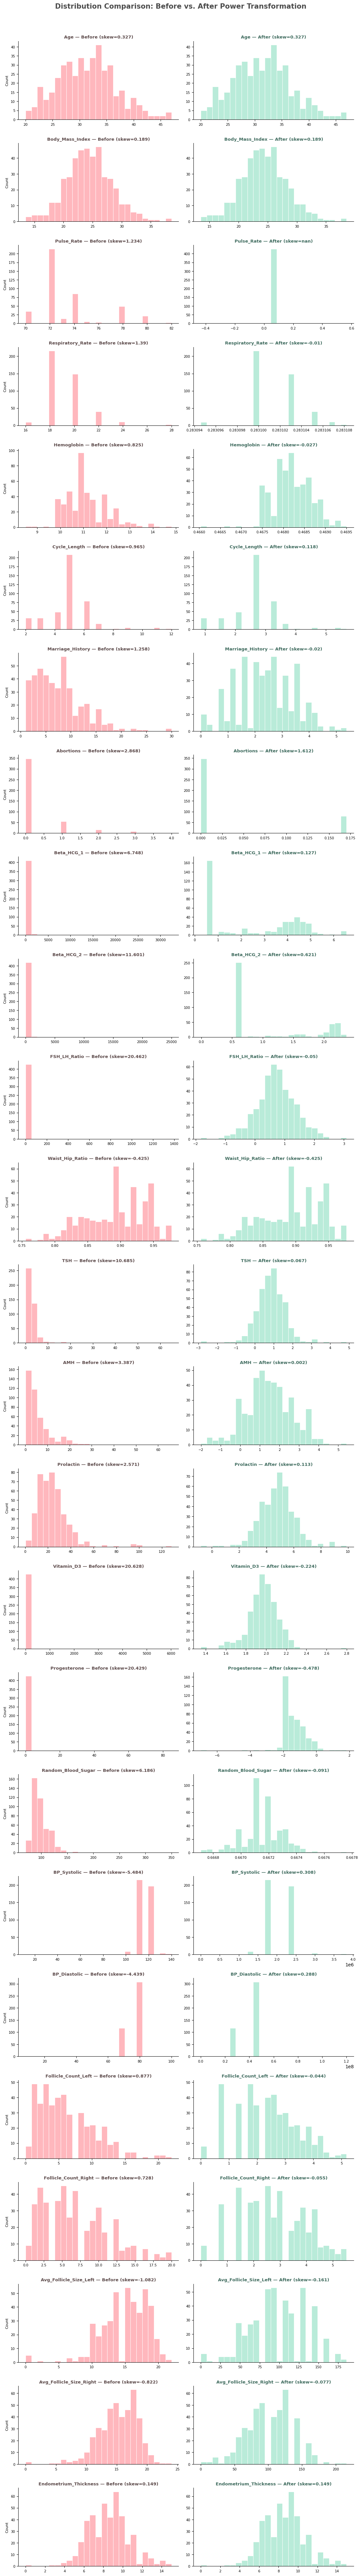

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pastel palette: soft coral for "before", soft teal for "after"
color_before = "#FFB3BA"   # pastel pink/coral
color_after = "#B5EAD7"    # pastel mint/teal

n_features = len(numeric_features)
n_cols = 2  # before | after
n_rows = n_features

fig, axes = plt.subplots(n_rows, n_cols, figsize=(11, 3.1 * n_rows))
fig.patch.set_facecolor("white")

sns.set_style("whitegrid", {"grid.linestyle": ":", "grid.color": "#e0e0e0"})

for i, feature in enumerate(numeric_features):
    skew_before = skewness_comparison_df.loc[skewness_comparison_df["Feature"] == feature, "Before"].values[0]
    skew_after = skewness_comparison_df.loc[skewness_comparison_df["Feature"] == feature, "After"].values[0]

    # --- Before ---
    ax_before = axes[i, 0]
    ax_before.hist(
        X_train_num[feature],
        bins=25,
        color=color_before,
        edgecolor="white",
        linewidth=0.8,
        alpha=0.95
    )
    ax_before.set_title(f"{feature} — Before (skew={skew_before})", fontsize=9.5, fontweight="bold", color="#5c4a4a")
    ax_before.set_ylabel("Count", fontsize=8)
    ax_before.tick_params(labelsize=7.5)
    for spine in ["top", "right"]:
        ax_before.spines[spine].set_visible(False)

    # --- After ---
    ax_after = axes[i, 1]
    ax_after.hist(
        X_train_num_power[feature],
        bins=25,
        color=color_after,
        edgecolor="white",
        linewidth=0.8,
        alpha=0.95
    )
    ax_after.set_title(f"{feature} — After (skew={skew_after})", fontsize=9.5, fontweight="bold", color="#3f6b5e")
    ax_after.tick_params(labelsize=7.5)
    for spine in ["top", "right"]:
        ax_after.spines[spine].set_visible(False)

fig.suptitle(
    "Distribution Comparison: Before vs. After Power Transformation",
    fontsize=15, fontweight="bold", color="#4a4a4a", y=1.001
)
plt.tight_layout(rect=[0, 0, 1, 0.995])
plt.show()

/tmp/ipykernel_2428/4078134659.py:5: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  after = skew(X_train_num_power[col], bias = False)


,Feature,Before,After
0,Age,0.327,0.327
1,Body_Mass_Index,0.189,0.189
2,Pulse_Rate,1.234,NaN
3,Respiratory_Rate,1.390,-0.010
4,Hemoglobin,0.825,-0.027
5,Cycle_Length,0.965,0.118
6,Marriage_History,1.258,-0.020
7,Abortions,2.868,1.612
8,Beta_HCG_1,6.748,0.127
9,Beta_HCG_2,11.601,0.621


# L1 Regularization

In logistic regression, the model estimates coefficients for the predictors. If the coefficients become excessively large, the model can become overly sensitive to the training data and may generalize poorly to new observations. Regularization addresses this by adding a penalty for large coefficients to the model's optimization process.

L1 Regularization

L1 regularization adds a penalty based on the absolute values of the coefficients:

$$Penalty_{L1} =  λ∑∣βj​∣$$

where $$β_{j}$$

represents a predictor's coefficient and λ controls the strength of regularization.

An important characteristic of L1 is that it can force some coefficients to become exactly zero. Therefore, L1 can effectively perform feature selection: predictors that contribute little to the model may be removed from the final model.

For example:

Before L1:

- X1 coefficient = 2.3
- X2 coefficient = 0.8
- X3 coefficient = 0.05

After L1:

- X1 coefficient = 1.9
- X2 coefficient = 0.5
- X3 coefficient = 0.0

Here, X3 has effectively been removed from the model.

# L2 Regularization

L2 regularization instead penalizes the squared values of the coefficients:
$$Penalty_{L2}​ = λ∑β_j^2$$​

L2 tends to shrink coefficients toward zero, but normally does not make them exactly zero.

For example:

Before L2:

- X1 = 2.3
- X2 = 0.8
- X3 = 0.05

After L2:

- X1 = 1.7
- X2 = 0.6
- X3 = 0.03

So the key distinction is:

| L1                                 | L2                              |
| ---------------------------------- | ------------------------------- |
| Uses absolute coefficient values   | Uses squared coefficient values |
| Shrinks coefficients               | Shrinks coefficients            |
| Can make coefficients exactly zero | Usually does not make them zero |
| Can perform feature selection      | Usually retains all predictors  |


Both approaches are intended to control model complexity and reduce overfitting.

# Why StandardScaler is important here and its connection to L1 and L2

Our numerical predictors have very different units and scales. For example, we may have variables representing age, blood pressure, hormone concentrations, follicle counts, ratios, and other clinical measurements.

Suppose two predictors have very different ranges:

FSH_LH_Ratio:       0.2 to 3.0

BP_Systolic:       90 to 160

A coefficient cannot be compared fairly across predictors when a one-unit change has a completely different meaning for each variable.

This becomes particularly important with L1 and L2 regularization, **because regularization penalizes the sizes of the model coefficients**. Without scaling, the penalty can be affected by the measurement units of the predictors rather than only by their **predictive importance**.

StandardScaler standardizes each numerical predictor approximately as:

$$ z=(x - μ)/σ​ $$

where:

- x = original value
- μ = training-set mean
- σ = training-set standard deviation

After scaling, each numerical predictor in the training data has approximately:

- Mean = 0 and Standard Deviation = 1

For example, instead of working directly with systolic blood pressures such as:

> 110, 120, 130, 140, 150

the model might see standardized values roughly like:

> -1.41, -0.71, 0.00, 0.71, 1.41

The relative differences remain, but the measurement scale has changed.

Just like imputation and power transformations, **the scaler must be fitted only on the training data**.

## 7.3 Now, standardize and combine the predictors

After completing the numerical power transformations, standardize the numerical predictors and combine them with the previously encoded nominal predictors to create the final Stage 2 training and testing datasets.

1. Create a StandardScaler object called scaler_stage2.
2. Fit the scaler using the power-transformed numerical predictors from the training dataset. At the same time, transform these training predictors using fit_transform().
3. Convert the resulting scaled training data back into a pandas DataFrame. Preserve:
- the original numerical feature names using numeric_features;
- the original training row indices.
- Apply the same fitted scaler to the power-transformed numerical predictors in the test dataset using transform(). Do not use fit_transform() on the test dataset.
4. Convert the scaled test data back into a pandas DataFrame, again preserving the numerical feature names and test row indices.
5. Combine the scaled numerical training predictors with the previously one-hot-encoded nominal training predictors using pd.concat().
6. Combine the DataFrames horizontally using axis = 1.
7. Store the result as X_train_stage2.
8. Repeat the same process for the test dataset by combining the scaled numerical test predictors with the encoded nominal test predictors. Store the result as X_test_stage2.
9. Finally, display the shapes of X_train_stage2 and X_test_stage2. Verify that the two datasets have the same number of predictor columns, although they will normally contain different numbers of rows.

> reminder again: The scaler must be fitted only on the training data. The mean and standard deviation learned from the training data must then be used unchanged to standardize the test data. This prevents data leakage and ensures that the test set remains genuinely unseen by the model-building process.

In [40]:
from sklearn.preprocessing import StandardScaler

# 1. Create the scaler
scaler_stage2 = StandardScaler()

# 2 & 3. Fit on training data only, transform training data, rebuild as DataFrame
X_train_num_scaled = pd.DataFrame(
    scaler_stage2.fit_transform(X_train_num_power[numeric_features]),
    columns=numeric_features,
    index=X_train_num_power.index
)

# 4. Apply the SAME fitted scaler to the test data (transform only, no fit)
X_test_num_scaled = pd.DataFrame(
    scaler_stage2.transform(X_test_num_power[numeric_features]),
    columns=numeric_features,
    index=X_test_num_power.index
)

# 5-7. Combine scaled numerical predictors with encoded nominal predictors (training)
X_train_stage2 = pd.concat([X_train_num_scaled, X_train_nom_enc], axis=1)

# 8. Combine scaled numerical predictors with encoded nominal predictors (testing)
X_test_stage2 = pd.concat([X_test_num_scaled, X_test_nom_enc], axis=1)

# 9. Verify shapes
print("Stage 2 training shape:", X_train_stage2.shape)
print("Stage 2 testing shape:", X_test_stage2.shape)
print("Same number of columns:", X_train_stage2.shape[1] == X_test_stage2.shape[1])

Stage 2 training shape: (428, 41)
Stage 2 testing shape: (108, 41)
Same number of columns: True


Stage 2 training shape: (428, 41)
Stage 2 testing shape: (108, 41)


# Model evaluation metrics

After training a classification model, we need to determine how well it performs on observations that were not used to train it. Because our target variable is binary:

- 0 = No PCOS
- 1 = PCOS

the model's predictions can fall into four categories shown in the matrix below.

1. Confusion Matrix

The confusion matrix summarizes correct and incorrect predictions:

|                    |   Predicted No PCOS |      Predicted PCOS |
| ------------------ | ------------------: | ------------------: |
| **Actual No PCOS** |  True Negative (TN) | False Positive (FP) |
| **Actual PCOS**    | False Negative (FN) |  True Positive (TP) |


The four outcomes are:

True Positive (TP): Patient has PCOS and the model predicts PCOS.

True Negative (TN): Patient does not have PCOS and the model predicts no PCOS.

False Positive (FP): Patient does not have PCOS, but the model predicts PCOS.

False Negative (FN): Patient has PCOS, but the model predicts no PCOS.

The confusion matrix is the foundation for several of the metrics used below.

# 2. Accuracy

Accuracy measures the proportion of all predictions that were correct.

$$ Accuracy=(TP+TN)/(FP+FN+TP+TN) ​$$


For example, an accuracy of: 0.85 means that 85% of the test observations were classified correctly.

Accuracy is easy to understand, but it can be misleading when the classes are imbalanced. For example, if 90% of patients did not have PCOS, a model that always predicted "No PCOS" would achieve 90% accuracy despite being useless for identifying PCOS.

This is why we should not evaluate the model using accuracy alone.

# 3. Precision

Precision asks:

`Of all patients that the model predicted as having PCOS (positive), how many actually had PCOS?`

$$ Precision=TP/(FP+TP) ​$$

For example:

Precision = 0.80 means that 80% of the patients predicted to have PCOS actually had PCOS.

**High precision means the model produces relatively few false positives.**

# 4. Recall

Recall asks:

**Of all patients who actually had PCOS, how many did the model correctly identify?**

$$ Recall = TP/(FN+TP) ​$$

**Recall is also commonly called sensitivity or the true positive rate.**

For example: Recall = 0.90 means the model correctly identified 90% of the actual PCOS cases.

In a diagnostic context, recall can be particularly important because `low recall means the model is producing many false negatives—patients who actually have PCOS but are classified as not having it (these patients may not receive treatments!)`.

# 5. F1 Score

`Precision and recall sometimes work against each other. A model may achieve very high recall by predicting many observations as positive, but this can produce more false positives and reduce precision.`

**The F1 score combines precision and recall into a single metric using their harmonic mean:**

$$ F1=2(Precision*Recall)/(Precision + Recall​) $$

**An F1 score is high only when both precision and recall are reasonably high.**

For example:

- Precision = 0.90
- Recall    = 0.50

will not produce a very high F1 score because, despite good precision, the model is missing many actual positive cases.

F1 is therefore useful when we want a balance between precision and recall, `particularly when the classes are not perfectly balanced`.

# 6. Predicted class vs. predicted probability

The function that you will create below, generates two different types of predictions:

> y_pred = model.predict(X_test)

y_pred contains the model's final class predictions:

0, 1, 0, 0, 1, 1, ...

**These predictions are used to calculate accuracy, precision, recall and F1**.

> Then

> y_prob = model.predict_proba(X_test)[:, 1]

returns the model's estimated probability of belonging to class 1 (PCOS).

For example:

0.08

0.74

0.35

0.91

A patient with 0.91 has an estimated 91% probability of belonging to the positive class according to the fitted model.

The: [: , 1] selects the probability associated with class 1, which in our case is PCOS.

#7. ROC curve

The Receiver Operating Characteristic (ROC) curve `evaluates the classifier over many possible classification thresholds.`

Normally, a probability such as:0.82 might be converted to class 1, while: 0.31
might become class 0.

**But what if we changed the decision threshold?**

Instead of evaluating only one threshold, the ROC curve examines how the model behaves across many thresholds.

It plots: True Positive Rate (TPR)

against: False Positive Rate (FPR)

where:

$$ TPR= TP /(TP+FN)$$

and:

$$ FPR = FP/(FP+TN) $$

Notice that TPR is the same as recall(sensitivity).

A good ROC curve generally moves toward the upper-left corner, representing high sensitivity with relatively few false positives.

> The terminology depends mostly on the field: **sensitivity** is very common in medicine and diagnostic testing, while **recall** is more common in machine learning and data science.

The counterpart is `**specificity**`:

$$ Specificity = TN/ (TN+FP) $$
	​


> `Sensitivity asks, How well do we identify PCOS patients?`

> `Specificity asks, How well do we identify non-PCOS patients?`

# 8. ROC-AUC

The Area Under the ROC Curve (ROC-AUC) summarizes the ROC curve with a single number.

Generally:

|   ROC - AUC   | Interpretation                          |
| --------:   | --------------------------------------- |
|      0.50   | No discrimination; approximately random |
| 0.60 - 0.70 | Weak discrimination                     |
| 0.70 - 0.80 | Acceptable/moderate discrimination      |
| 0.80 - 0.90 | Good discrimination                     |
| 0.90 - 1.00 | Excellent discrimination                |

* discrimination here means, the model's ability to distinguish between the two classes.

These ranges are only general guidelines, not universal rules.

An AUC of: 0.88 means that the model has good ability to distinguish between the positive and negative classes across possible classification thresholds.

**Unlike accuracy, ROC-AUC is calculated from the model's `predicted probabilities` rather than just its final 0/1 predictions.**

# 9. Classification Report


`classification_report(y_test, y_pred)`

The classification report provides several metrics for each class separately, including:

- precision,
- recall,
- F1 score,
- support

**support simply represents the number of actual observations belonging to each class in the test dataset.**

The report also includes overall summaries such as accuracy, macro average, and weighted average.

This is particularly useful because a single overall metric can hide differences in how well the model predicts PCOS versus non-PCOS patients.



# Now, create a function for model evaluation

Create a reusable Python function that trains a logistic regression model and evaluates its performance on the test dataset.

1. Define a function named evaluate_model() that accepts six arguments: the model, model name, training predictors, testing predictors, training target, and testing target.

2. Inside the function, fit the supplied model using X_train and y_train.

3. Use the fitted model to generate two types of test-set predictions:
- Use predict() to obtain the predicted class (0 or 1) for each observation.
- Use predict_proba() to obtain the predicted probability of the positive class (PCOS = 1). Select the second probability column using [:, 1].
- Calculate the following evaluation metrics by comparing the actual test values with the model predictions:
- Accuracy
- F1 score
- Precision
- Recall
- ROC-AUC

4. Display the model name followed by the five evaluation metrics. Format the metric values to four decimal places to make comparisons between models easier.

5. Generate and display a confusion matrix to show the numbers of true positives, true negatives, false positives and false negatives.

6. Generate a classification report containing precision, recall, F1 score and support for each target class. Display the results to four decimal places.

7. Use roc_curve() with the actual test values and predicted probabilities to calculate:
- FPR: False Positive Rate
- TPR: True Positive Rate

8. Return the model name, evaluation metrics, FPR and TPR in a Python dictionary. This will allow the results from several logistic regression models to be stored and compared later.

9. Use the same function to evaluate all logistic regression configurations in the activity rather than rewriting the evaluation code for every model.

> Important: All performance metrics in this function are calculated using the test dataset, which was not used to fit the model. This provides a more realistic assessment of how well the model generalizes to previously unseen observations.

In [41]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np


def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):
    """
    Trains a logistic regression model, evaluates it on the test set,
    prints key metrics, a confusion matrix visualization, and a
    classification report, and returns the results in a dictionary.
    """

    # 2. Fit the model
    model.fit(X_train, y_train)

    # 3. Generate predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Evaluation metrics (test set only)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    # 4. Display model name and metrics
    print(f"===== {model_name} =====")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")

    # 5. Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # --- Beautiful pastel confusion matrix visualization ---
    pastel_cmap = mcolors.LinearSegmentedColormap.from_list(
        "pastel_mint_coral", ["#FFE3E3", "#FFF6D9", "#D8F3DC", "#B5EAD7"]
    )

    fig, ax = plt.subplots(figsize=(5.5, 5))
    im = ax.imshow(cm, cmap=pastel_cmap)

    labels = ["No PCOS (0)", "PCOS (1)"]
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel("Predicted Label", fontsize=11, fontweight="bold", labelpad=10)
    ax.set_ylabel("Actual Label", fontsize=11, fontweight="bold", labelpad=10)
    ax.set_title(f"Confusion Matrix — {model_name}", fontsize=13, fontweight="bold", pad=15)

    cell_labels = np.array([["TN", "FP"], ["FN", "TP"]])
    max_val = cm.max()

    for i in range(2):
        for j in range(2):
            count = cm[i, j]
            text_color = "#3f3f3f" if count < max_val * 0.7 else "white"
            ax.text(
                j, i, f"{cell_labels[i, j]}\n{count}",
                ha="center", va="center",
                fontsize=13, fontweight="bold", color=text_color
            )

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks(np.arange(-0.5, 2, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 2, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=3)
    ax.tick_params(which="minor", bottom=False, left=False)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Number of Observations", fontsize=9)

    plt.tight_layout()
    plt.show()

    # 6. Classification report
    report = classification_report(y_test, y_pred, digits=4)
    print("\nClassification Report:")
    print(report)

    # 7. ROC curve values
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    # 8. Return results dictionary
    results = {
        "model_name": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "fpr": fpr,
        "tpr": tpr
    }

    return results

# Create and evaluating the stage 2 Logistic Regression models

Using the fully preprocessed Stage 2 data (including imputation, power transformation, scaling, and one-hot encoding) create and compare three logistic regression models with different solver and regularization settings.

1. Create a dictionary named stage2_models. Use descriptive names as the dictionary keys and the corresponding LogisticRegression models as the values.

2. Create the first model using the default logistic regression settings. Set max_iter = 2000 to allow sufficient iterations for the model to converge, and use the previously defined RANDOM_STATE for reproducibility.

3. Create a second model using the liblinear solver with L1 regularization. Set:
- solver = "liblinear"
- l1_ratio = 1 to specify L1 regularization
- max_iter = 2000
- random_state = RANDOM_STATE

4. Create a third model using the liblinear solver with L2 regularization. Set:
- solver = "liblinear"
- l1_ratio = 0 to specify L2 regularization
- max_iter=2000
- random_state=RANDOM_STATE

5. Create an empty list named stage2_results. This list will be used to store the performance results returned for each model.

6. Use a for loop with .items() to iterate through the stage2_models dictionary. For each iteration, retrieve both the model name and the corresponding logistic regression model.

7. Inside the loop, call the previously created evaluate_model() function. Pass the following information to the function:

current logistic regression model,

model name,

X_train_stage2,

X_test_stage2,

y_train,

y_test.

8. Store the dictionary returned by evaluate_model() in a variable named result.

9. Append each model's results to the stage2_results list. At the end of the loop, this list should contain the evaluation results for all three Stage 2 models.

10. Review and compare the reported accuracy, precision, recall, F1 score, ROC-AUC, confusion matrix, and classification report for the three models.
Purpose of this step

> The objective is to determine whether different solver and regularization configurations affect the performance of logistic regression when applied to the same preprocessed dataset. Because all three models receive exactly the same training and testing data, differences in their performance can be attributed to their model configuration rather than differences in preprocessing.

Stage 2 - Default
===== Stage 2 - Default =====
Accuracy:  0.8704
Precision: 0.8387
Recall:    0.7429
F1 Score:  0.7879
ROC-AUC:   0.9546


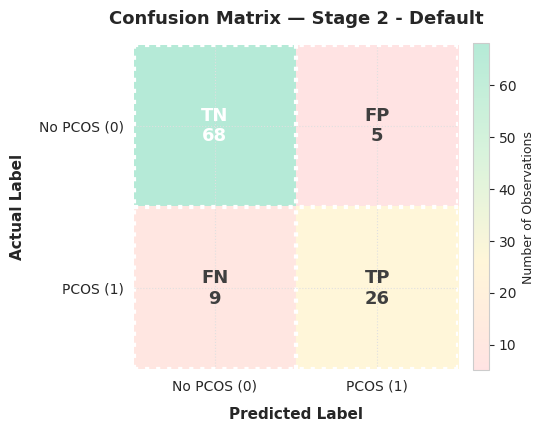


Classification Report:
              precision    recall  f1-score   support

           0     0.8831    0.9315    0.9067        73
           1     0.8387    0.7429    0.7879        35

    accuracy                         0.8704       108
   macro avg     0.8609    0.8372    0.8473       108
weighted avg     0.8687    0.8704    0.8682       108


Stage 2 - Liblinear L1
===== Stage 2 - Liblinear L1 =====
Accuracy:  0.8704
Precision: 0.8387
Recall:    0.7429
F1 Score:  0.7879
ROC-AUC:   0.9511


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


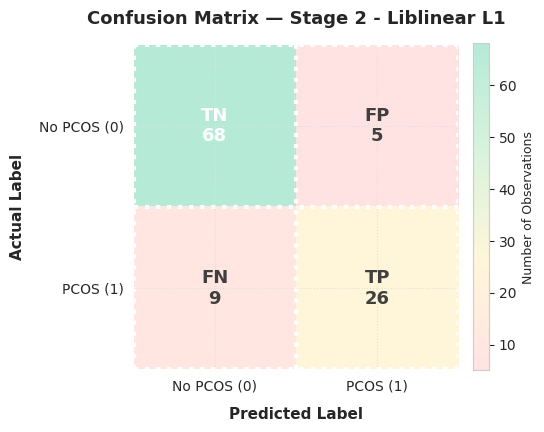


Classification Report:
              precision    recall  f1-score   support

           0     0.8831    0.9315    0.9067        73
           1     0.8387    0.7429    0.7879        35

    accuracy                         0.8704       108
   macro avg     0.8609    0.8372    0.8473       108
weighted avg     0.8687    0.8704    0.8682       108


Stage 2 - Liblinear L2
===== Stage 2 - Liblinear L2 =====
Accuracy:  0.8704
Precision: 0.8387
Recall:    0.7429
F1 Score:  0.7879
ROC-AUC:   0.9511


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


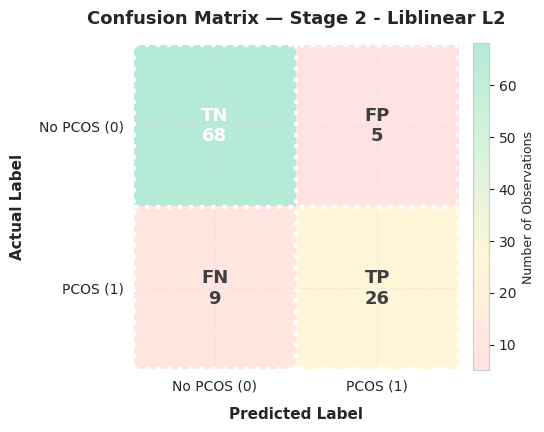


Classification Report:
              precision    recall  f1-score   support

           0     0.8831    0.9315    0.9067        73
           1     0.8387    0.7429    0.7879        35

    accuracy                         0.8704       108
   macro avg     0.8609    0.8372    0.8473       108
weighted avg     0.8687    0.8704    0.8682       108




In [42]:
from sklearn.linear_model import LogisticRegression

# 1. Dictionary of Stage 2 model configurations
stage2_models = {
    "Stage 2 - Default": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
    "Stage 2 - Liblinear L1": LogisticRegression(
        solver="liblinear",
        l1_ratio=1,
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
    "Stage 2 - Liblinear L2": LogisticRegression(
        solver="liblinear",
        l1_ratio=0,
        max_iter=2000,
        random_state=RANDOM_STATE
    )
}

# 5. Storage for results
stage2_results = []

# 6-9. Loop through each model, evaluate, and store results
for model_name, model in stage2_models.items():
    print("=" * 70)
    print(model_name)
    print("=" * 70)

    result = evaluate_model(
        model,
        model_name,
        X_train_stage2,
        X_test_stage2,
        y_train,
        y_test
    )

    stage2_results.append(result)
    print()

Stage 2 - Default
Accuracy:  0.8704
F1 Score:  0.7879
Precision: 0.8387
Recall:    0.7429
ROC-AUC:   0.9546

Confusion Matrix:
[[68  5]
 [ 9 26]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8831    0.9315    0.9067        73
           1     0.8387    0.7429    0.7879        35

    accuracy                         0.8704       108
   macro avg     0.8609    0.8372    0.8473       108
weighted avg     0.8687    0.8704    0.8682       108

Stage 2 - Liblinear L1
Accuracy:  0.8704
F1 Score:  0.7879
Precision: 0.8387
Recall:    0.7429
ROC-AUC:   0.9511

Confusion Matrix:
[[68  5]
 [ 9 26]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8831    0.9315    0.9067        73
           1     0.8387    0.7429    0.7879        35

    accuracy                         0.8704       108
   macro avg     0.8609    0.8372    0.8473       108
weighted avg     0.8687    0.8704    0.8682       108

S

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


## 9.1 Stage 2 ROC curves

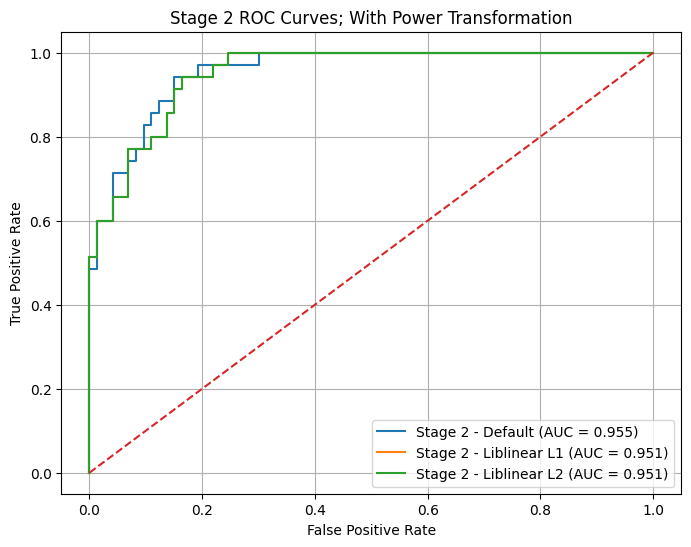

# 10. Stage 3 - Logistic Regression without numerical power transformation

Stage 3 uses the **same split, same training-only imputation, and same categorical encoding**.

The only intended difference is that numerical predictors are **not Box-Cox/Yeo-Johnson transformed**.

They are still standardized because scaling is important when comparing regularized logistic-regression models.

Stage 3 training shape: (428, 41)
Stage 3 testing shape: (108, 41)


# 11. Stage 3 models

Stage 3 - Default
Accuracy:  0.8796
F1 Score:  0.8060
Precision: 0.8438
Recall:    0.7714
ROC-AUC:   0.9534

Confusion Matrix:
[[68  5]
 [ 8 27]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8947    0.9315    0.9128        73
           1     0.8438    0.7714    0.8060        35

    accuracy                         0.8796       108
   macro avg     0.8692    0.8515    0.8594       108
weighted avg     0.8782    0.8796    0.8781       108

Stage 3 - Liblinear L1
Accuracy:  0.8889
F1 Score:  0.8235
Precision: 0.8485
Recall:    0.8000
ROC-AUC:   0.9519

Confusion Matrix:
[[68  5]
 [ 7 28]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9067    0.9315    0.9189        73
           1     0.8485    0.8000    0.8235        35

    accuracy                         0.8889       108
   macro avg     0.8776    0.8658    0.8712       108
weighted avg     0.8878    0.8889    0.8880       108

S

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


## 11.1 Stage 3 ROC curves

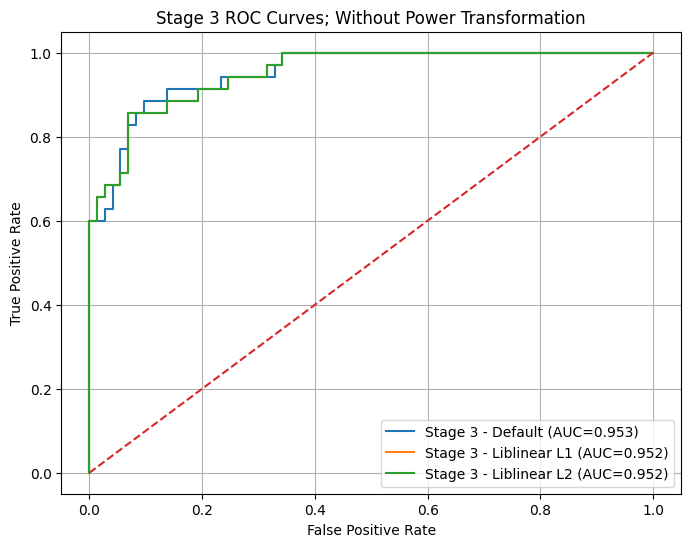

# 12. Compare all six models

,Model,Accuracy,F1,Precision,Recall,ROC_AUC
0,Stage 2 - Default,0.8704,0.7879,0.8387,0.7429,0.9546
1,Stage 3 - Default,0.8796,0.8060,0.8438,0.7714,0.9534
2,Stage 3 - Liblinear L2,0.8889,0.8235,0.8485,0.8000,0.9519
3,Stage 3 - Liblinear L1,0.8889,0.8235,0.8485,0.8000,0.9519
4,Stage 2 - Liblinear L1,0.8704,0.7879,0.8387,0.7429,0.9511
5,Stage 2 - Liblinear L2,0.8704,0.7879,0.8387,0.7429,0.9511


## 12.1 ROC curves for all six models

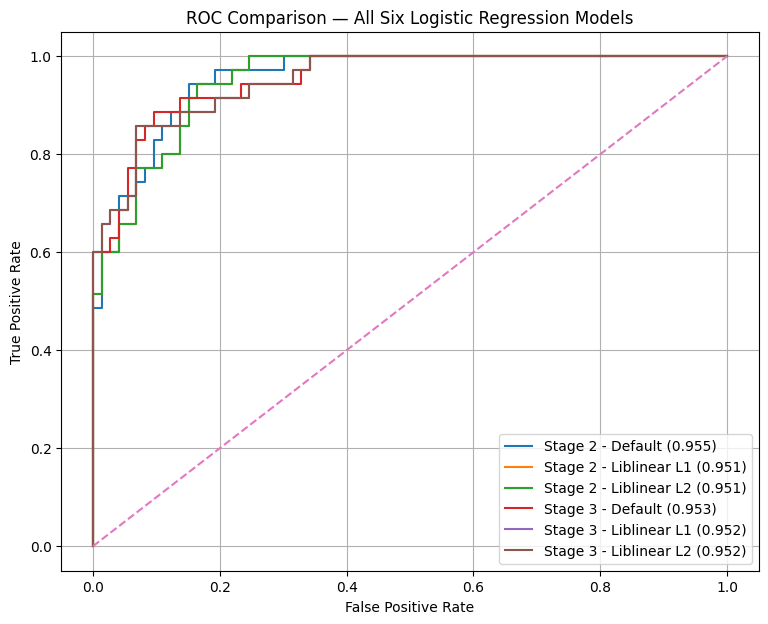

# 13. Reflection Questions with sample responses

### 1. Which performance metric is most reliable?

There is no universally best metric. Because this is a diagnostic classification problem, **accuracy alone is insufficient**.  
Important measures include:

- **Recall / sensitivity for PCOS = 1**, because false negatives may be costly.

- **Precision**, because excessive false positives are also undesirable.

- **F1 score**, when a balance between precision and recall is useful.

- **ROC-AUC**, for overall discrimination across classification thresholds.

For an actual medical application, the preferred metric must be chosen according to the clinical costs of false negatives and false positives.

### 2. Which solver and regularization approach seem suitable?

- `liblinear` is reasonable for a relatively small binary classification problem and supports both L1 and L2 regularization.  

- L1 can produce sparse coefficients and perform a form of feature selection.  

- L2 generally shrinks coefficients without forcing many of them exactly to zero.

The best choice should be based on validation performance rather than assumed in advance.

### 3. Which implemented model performs best?

Use the comparison table above. Rank models by ROC-AUC, but also inspect recall, F1, and the confusion matrix.

An important learning outcome is that **power transformation does not automatically improve logistic-regression performance**.

### 4. Are the results sufficient for a reliable clinical model?

Good test-set performance in this notebook is **not enough to establish clinical reliability**.  
Possible improvements include:

- repeated stratified cross-validation,
- hyperparameter tuning for `C`,
- class-weight investigation,
- feature selection,
- multicollinearity analysis,
- probability calibration,
- threshold optimization,
- larger and more diverse data,
- and, most importantly, external validation on an independent dataset.
